# UNet Training v14

## Cell Guide

| Cell | Purpose |
|------|---------|
| **1 — Environment** | Verifies GPU is available and checks free disk space. Raises an error if no GPU is detected. |
| **2 — Setup** | Defines paths, the `run_with_dots` thread helper for keeping Colab alive during long ops, and downloads `slice_index.json` from HuggingFace. |
| **3 — Imports** | Installs and imports all required packages including `albumentations` for augmentation and `h5py` for HDF5 reading. |
| **4 — Hyperparameters** | Sets training configuration: learning rate, batch size, number of epochs, patience for early stopping, and train/val/test split ratios. |
| **5 — Model** | Defines `UNetV2`, a 4-level encoder-decoder architecture with skip connections, Instance Normalisation, and ReLU activations. |
| **6 — Helpers** | Defines all training utilities: loss functions, metrics, HDF5 dataset class, dataloader builder, and checkpoint/log save-load functions. |
| **7 — Pre-flight** | Downloads `slices.h5` from HuggingFace if not already local, builds dataloaders, initialises the model, and loads the latest checkpoint to support resuming. |
| **8 — Training** | Runs the training loop. Saves `latest.pth` and `best.pth` to HuggingFace after every epoch. Logs all metrics to `train_log.json` on HuggingFace. Supports early stopping. |
| **9 — Evaluation** | Downloads `best.pth` from HuggingFace and evaluates the best model on the held-out test set. Reports all metrics. |
| **10 — Visualization** | Displays 4 random validation samples side by side: CT slice, ground truth mask, and predicted mask with Dice score. |


---

## Metrics

All metrics are computed at a threshold of 0.5 on the sigmoid output. Let TP, FP, FN, TN denote true positives, false positives, false negatives, and true negatives at the pixel level.

| Metric | Formula | What it measures |
|--------|---------|------------------|
| **Dice** | 2·TP / (2·TP + FP + FN) | Overlap between predicted and ground truth mask. The primary metric — ranges from 0 (no overlap) to 1 (perfect overlap). |
| **IoU** | TP / (TP + FP + FN) | Intersection over Union — stricter than Dice, penalises over- and under-segmentation more heavily. Also called Jaccard index. |
| **Sensitivity** | TP / (TP + FN) | Fraction of actual lung pixels correctly identified. High sensitivity means the model misses few lung regions. Also called recall or true positive rate. |
| **Specificity** | TN / (TN + FP) | Fraction of actual non-lung pixels correctly identified. High specificity means the model rarely predicts lung where there is none. Also called true negative rate. |
| **Loss** | 0.5 × BCE + 0.5 × Dice loss | Combined loss used during training. BCE handles per-pixel accuracy; Dice loss handles region-level overlap. Both are needed since BCE alone can ignore small structures. |

---

## Data & Architecture Notes
- **Input:** 128×128 grayscale CT slices, normalised to [0, 1]
- **Output:** 128×128 binary lung mask
- **Dataset:** 107,238 slices from 996 patients (LIDC-IDRI), stored as a single `slices.h5` HDF5 file on HuggingFace
- **Split:** Patient-level (no patient appears in more than one split) — 80% train / 10% val / 10% test
- **Augmentation (train only):** horizontal flip, vertical flip, rotation ±15°, brightness/contrast jitter, Gaussian blur, Gaussian noise
- **Architecture:** UNetV2 — 4 encoder levels (32→64→128→256 channels), bottleneck (512 channels), 4 symmetric decoder levels with skip connections

In [ ]:
# ============================================================
# CELL 1 — Environment check
# ============================================================
import torch, platform, shutil

print("=" * 55)
print("ENVIRONMENT")
print("=" * 55)
print(f"Python  : {platform.python_version()}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU     : {props.name}")
    print(f"VRAM    : {props.total_memory / 1e9:.1f} GB")
else:
    raise RuntimeError(
        "No GPU detected.\n"
        "Go to Runtime > Change runtime type > T4 GPU, then re-run."
    )
disk = shutil.disk_usage("/")
print(f"Disk    : {disk.free / 1e9:.1f} GB free")
print("=" * 55)
print("[Cell 1 OK]")

ENVIRONMENT
Python  : 3.12.13
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB
Disk    : 74.1 GB free
[Cell 1 OK]


In [ ]:
# ============================================================
# CELL 2 — Paths, helpers, index download
# Data source : slices.h5 downloaded from HF once per session
# Checkpoints : HF only — no Drive writes
# Drive       : mounted only to keep Colab happy; never read
#               from during training
# ============================================================
import os, json, time, torch, threading, shutil
from huggingface_hub import hf_hub_download, HfApi

# ── Worker-thread helper ─────────────────────────────────────
# Runs any blocking fn() on a thread so the main thread stays
# free to print heartbeats and keep the Colab session alive.
# Short ops  (<heartbeat): prints dots every second
# Long ops  (>=heartbeat): prints timestamped newlines every
#   heartbeat seconds — newlines reset Colab's idle timer
def run_with_dots(fn, label, dot_interval=1.0, timeout=180, heartbeat=30):
    result = [None]; error = [None]; done = threading.Event()
    def worker():
        try:    result[0] = fn()
        except Exception as e: error[0] = e
        finally: done.set()
    t = threading.Thread(target=worker, daemon=True)
    print(label, end="", flush=True)
    t.start()
    elapsed = 0.0; last_beat = 0.0
    while not done.wait(dot_interval):
        elapsed += dot_interval
        if elapsed >= timeout:
            error[0] = TimeoutError("Timed out after " + str(timeout) + "s")
            done.set(); break
        if elapsed - last_beat >= heartbeat:
            print(f"\n  [{time.strftime('%H:%M:%S')}] still waiting... ({int(elapsed)}s)",
                  flush=True)
            last_beat = elapsed
        else:
            print(".", end="", flush=True)
    t.join(timeout=2)
    if error[0] is not None: raise error[0]
    return result[0]

# ── Paths ────────────────────────────────────────────────────
LOCAL_META     = "/content/slice_index.json"
CHECKPOINT_DIR = "/content"        # local staging only — uploads go to HF
HF_REPO        = "hourouu/data_unet128A"
H5_LOCAL       = "/content/slices.h5"  # HDF5 — single file, no FUSE

print("HF repo        : " + HF_REPO)
print("HDF5 local     : " + H5_LOCAL)
print("Checkpoint dir : " + CHECKPOINT_DIR + "  (local staging, HF is source of truth)")

# ── Download slice_index.json from HF ────────────────────────
if os.path.exists(LOCAL_META):
    print("slice_index.json already local — skipping.", flush=True)
else:
    run_with_dots(
        lambda: hf_hub_download(
            repo_id=HF_REPO, filename="slice_index.json",
            repo_type="dataset", local_dir="/content"),
        "Downloading slice_index.json from HF", timeout=120)
    print(" done (" + str(round(os.path.getsize(LOCAL_META)/1e6, 1)) + " MB).",
          flush=True)

with open(LOCAL_META) as f:
    _idx = json.load(f)
_nl = sum(1 for s in _idx["slices"] if s["kind"] == "lung")
_ne = sum(1 for s in _idx["slices"] if s["kind"] == "empty")
print("Index: " + str(len(_idx["slices"])) + " slices (" +
      str(_nl) + " lung + " + str(_ne) + " empty)")
print("[Cell 2 OK]")

HF repo        : hourouu/data_unet128A
HDF5 local     : /content/slices.h5
Checkpoint dir : /content  (local staging, HF is source of truth)

slice_index.json: 0.00B [00:00, ?B/s]

. done (8.9 MB).
Index: 107238 slices (97624 lung + 9614 empty)
[Cell 2 OK]


In [ ]:
# ============================================================
# CELL 3 — Imports
# ============================================================
import subprocess, sys
for pkg in ["albumentations", "h5py"]:
    try: __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import os, json, time, random, threading
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import h5py
from torch.utils.data import DataLoader, Dataset

try:
    import albumentations as A
    ALBUMENTATIONS_AVAILABLE = True
    print("albumentations : OK")
except ImportError:
    ALBUMENTATIONS_AVAILABLE = False
    print("WARNING: albumentations not available — augmentation disabled")

print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
print("[Cell 3 OK]")

albumentations : OK
PyTorch 2.10.0+cu128 | CUDA: True
[Cell 3 OK]


In [ ]:
# ============================================================
# CELL 4 — Hyperparameters
# ============================================================
assert "HF_REPO" in globals(), "Run Cell 2 first."

SPLIT_SEED    = 42
VAL_FRACTION  = 0.10
TEST_FRACTION = 0.10
BATCH_SIZE    = 8
LR            = 1e-4
N_EPOCHS      = 50
PATIENCE      = 10
PRINT_EVERY   = 100

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Configuration:")
print(f"  Split seed   : {SPLIT_SEED}")
print(f"  Val fraction : {VAL_FRACTION}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  LR           : {LR}")
print(f"  Epochs       : {N_EPOCHS}")
print(f"  Patience     : {PATIENCE}")
print(f"  Print every  : {PRINT_EVERY} batches")
print(f"  Device       : {DEVICE}")
print("[Cell 4 OK]")

Configuration:
  Split seed   : 42
  Val fraction : 0.1
  Batch size   : 8
  LR           : 0.0001
  Epochs       : 50
  Patience     : 10
  Print every  : 100 batches
  Device       : cuda
[Cell 4 OK]


In [ ]:
# ============================================================
# CELL 5 — Model definition
# UNetV2: 4-level encoder/decoder with skip connections
# ============================================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNetV2(nn.Module):
    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        b = base_ch
        # Encoder
        self.enc1 = ConvBlock(in_ch, b);   self.enc2 = ConvBlock(b,   b*2)
        self.enc3 = ConvBlock(b*2,  b*4);  self.enc4 = ConvBlock(b*4, b*8)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = ConvBlock(b*8, b*16)
        # Decoder
        self.up4  = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = ConvBlock(b*16, b*8)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.dec3 = ConvBlock(b*8,  b*4)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.dec2 = ConvBlock(b*4,  b*2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec1 = ConvBlock(b*2,  b)
        # Output — single channel sigmoid mask
        self.out  = nn.Conv2d(b, 1, 1)

    def forward(self, x):
        s1 = self.enc1(x);               s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2));   s4 = self.enc4(self.pool(s3))
        b  = self.bottleneck(self.pool(s4))
        d4 = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        return self.out(d1)

_m = UNetV2()
print(f"UNetV2 | Parameters: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m
print("[Cell 5 OK]")

UNetV2 | Parameters: 7,762,465
[Cell 5 OK]


In [ ]:
# ============================================================
# CELL 6 — Helpers: loss, metrics, dataset, dataloaders,
#           checkpoint save/load, log save
# ============================================================
assert "DEVICE"  in globals(), "Run Cell 4 first."
assert "H5_LOCAL" in globals(), "Run Cell 2 first."


# ── Loss ─────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1); t = targets.view(-1)
        return 1-(2*(p*t).sum()+self.smooth)/(p.sum()+t.sum()+self.smooth)

class CombinedLoss(nn.Module):
    """50% BCE + 50% Dice — balances pixel-wise and region-wise errors."""
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(); self.dice = DiceLoss()
        self.bw, self.dw = bce_weight, dice_weight
    def forward(self, logits, targets):
        return self.bw*self.bce(logits,targets) + self.dw*self.dice(logits,targets)


# ── Metrics ──────────────────────────────────────────────────
@torch.no_grad()
def compute_metrics(logits, targets, threshold=0.5, eps=1e-6):
    preds = (torch.sigmoid(logits) > threshold).float(); t = targets.float()
    tp=(preds*t).sum(); fp=(preds*(1-t)).sum()
    fn=((1-preds)*t).sum(); tn=((1-preds)*(1-t)).sum()
    return {
        "dice":        ((2*tp+eps)/(2*tp+fp+fn+eps)).item(),
        "iou":         ((tp+eps)/(tp+fp+fn+eps)).item(),
        "sensitivity": ((tp+eps)/(tp+fn+eps)).item(),
        "specificity": ((tn+eps)/(tn+fp+eps)).item(),
    }


# ── Dataset ──────────────────────────────────────────────────
# Reads directly from the local HDF5 file by integer index.
# HDF5 handle opened once per instance — no per-item open/close overhead.
# No Drive, no FUSE, no network during training.
class CachedSliceDataset(Dataset):
    def __init__(self, indices, augment=False):
        self.indices = indices
        self.augment = augment and ALBUMENTATIONS_AVAILABLE
        if self.augment:
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                A.Rotate(limit=15, p=0.4),
                A.RandomBrightnessContrast(
                    brightness_limit=0.1, contrast_limit=0.1, p=0.3),
                A.GaussianBlur(blur_limit=(3, 5), p=0.2),
                A.GaussNoise(p=0.2),
            ])
        self._h5 = h5py.File(H5_LOCAL, "r")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        try:
            img = self._h5["img"][i]   # (H, W) float32
            msk = self._h5["msk"][i]   # (H, W) float32
        except Exception as e:
            print("\n  [Dataset] HDF5 read failed at index " +
                  str(i) + ": " + str(e), flush=True)
            return None
        if self.augment:
            aug = self.transform(image=img, mask=msk)
            img, msk = aug["image"], aug["mask"]
        return (torch.from_numpy(img).unsqueeze(0),
                torch.from_numpy(msk).unsqueeze(0))

    def __del__(self):
        try: self._h5.close()
        except: pass


def collate_skip_none(batch):
    batch = [b for b in batch if b is not None]
    if not batch: return None
    return torch.utils.data.dataloader.default_collate(batch)


# ── Dataloaders ──────────────────────────────────────────────
# Patient-level split prevents data leakage across splits.
# Reads kinds from HDF5 — source of truth for failed filtering.
# slice_index JSON does not contain kind="failed" entries since
# those are only written during packing, not back to the index.
def build_dataloaders(slice_index, val_frac=0.15, test_frac=0.05,
                      batch_size=8, seed=42):
    with h5py.File(H5_LOCAL, "r") as hf:
        hdf5_kinds = [k.decode() if isinstance(k, bytes) else str(k)
                      for k in hf["kind"][:]]

    valid = [(i, s) for i, (s, k) in
             enumerate(zip(slice_index["slices"], hdf5_kinds))
             if k != "failed"]

    all_pts = list(set(s["patient"] for _, s in valid))
    random.seed(seed); random.shuffle(all_pts)
    n          = len(all_pts)
    n_test     = max(1, int(n * test_frac))
    n_val      = max(1, int(n * val_frac))
    n_train    = n - n_val - n_test
    train_pids = set(all_pts[:n_train])
    val_pids   = set(all_pts[n_train:n_train + n_val])
    test_pids  = set(all_pts[n_train + n_val:])

    train_idx = [i for i, s in valid if s["patient"] in train_pids]
    val_idx   = [i for i, s in valid if s["patient"] in val_pids]
    test_idx  = [i for i, s in valid if s["patient"] in test_pids]

    for name, idx_list, pids in [
        ("train", train_idx, train_pids),
        ("val",   val_idx,   val_pids),
        ("test",  test_idx,  test_pids)
    ]:
        nl = sum(1 for i in idx_list if hdf5_kinds[i] == "lung")
        ne = sum(1 for i in idx_list if hdf5_kinds[i] == "empty")
        print("  " + name + " : " + str(len(pids)) + " patients, " +
              str(len(idx_list)) + " slices (" +
              str(nl) + " lung + " + str(ne) + " empty)")

    kw = dict(num_workers=0, pin_memory=True, collate_fn=collate_skip_none)
    return (
        DataLoader(CachedSliceDataset(train_idx, augment=True),
                   batch_size=batch_size, shuffle=True,  **kw),
        DataLoader(CachedSliceDataset(val_idx,   augment=False),
                   batch_size=batch_size, shuffle=False, **kw),
        DataLoader(CachedSliceDataset(test_idx,  augment=False),
                   batch_size=batch_size, shuffle=False, **kw),
    )


# ── Checkpoint helpers ───────────────────────────────────────
# All checkpoints go to HF. /content is staging only.
# save_checkpoint and save_log are non-fatal — training always
# continues even if an HF upload fails.
def save_checkpoint(state, filename, hf_repo):
    tmp = "/content/" + filename
    try:
        torch.save(state, tmp)
        run_with_dots(
            lambda: HfApi().upload_file(
                path_or_fileobj=tmp, path_in_repo=filename,
                repo_id=hf_repo, repo_type="dataset",
                commit_message="Epoch " + str(state["epoch"]) +
                               " | Dice " + str(round(state["best_dice"], 4))),
            "  Saving " + filename + " to HF", timeout=180)
        print(" done", flush=True)
    except Exception as e:
        print("\n  [WARN] HF checkpoint save failed: " + str(e) +
              " — training continues.", flush=True)
    finally:
        if os.path.exists(tmp): os.remove(tmp)


def load_checkpoint(model, optimizer, scheduler, hf_repo):
    """Load latest.pth from HF. Returns (start_epoch, best_dice, log)."""
    try:
        run_with_dots(
            lambda: hf_hub_download(
                repo_id=hf_repo, filename="latest.pth",
                repo_type="dataset", local_dir="/content",
                force_download=True),
            "  Loading checkpoint from HF", timeout=180)
        ckpt = torch.load("/content/latest.pth", map_location=DEVICE)
        print(" epoch " + str(ckpt["epoch"]) +
              " | Dice " + str(round(ckpt["best_dice"], 4)), flush=True)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        if scheduler and ckpt.get("scheduler_state"):
            scheduler.load_state_dict(ckpt["scheduler_state"])
        return ckpt["epoch"], ckpt["best_dice"], ckpt.get("log", []), ckpt.get("no_improve", 0)
    except Exception as e:
        print("\n  No checkpoint on HF (" + str(e) +
              ") — starting from epoch 1.", flush=True)
        return 0, 0.0, [], 0


def save_log(log, hf_repo):
    tmp = "/content/train_log.json"
    try:
        with open(tmp, "w") as f: json.dump(log, f, indent=2)
        run_with_dots(
            lambda: HfApi().upload_file(
                path_or_fileobj=tmp, path_in_repo="train_log.json",
                repo_id=hf_repo, repo_type="dataset",
                commit_message="Log update epoch " + str(log[-1]["epoch"])),
            "  Saving log to HF", timeout=120)
        print(" done", flush=True)
    except Exception as e:
        print("\n  [WARN] Log save failed: " + str(e), flush=True)
    finally:
        if os.path.exists(tmp): os.remove(tmp)


print("All helpers defined.")
print("[Cell 6 OK]")

All helpers defined.
[Cell 6 OK]


In [ ]:
# ============================================================
# CELL 7 — Pre-flight: HDF5 download, dataloaders,
#           model init, checkpoint load
# ============================================================
assert "HF_REPO"        in globals(), "Run Cell 2 first."
assert "H5_LOCAL"       in globals(), "Run Cell 2 first."
assert "DEVICE"         in globals(), "Run Cell 4 first."
assert "LOCAL_META"     in globals(), "Run Cell 2 first."
assert "CHECKPOINT_DIR" in globals(), "Run Cell 2 first."
assert os.path.exists(LOCAL_META),    "LOCAL_META missing — re-run Cell 2."

print("=" * 55, flush=True)
print("PRE-FLIGHT", flush=True)
print("=" * 55, flush=True)

# 1. Load index
print("\n1. Loading slice index...", flush=True)
with open(LOCAL_META) as f:
    slice_index = json.load(f)
n_patients = len(slice_index["processed_patients"])
n_slices   = len(slice_index["slices"])
n_lung     = sum(1 for s in slice_index["slices"] if s["kind"] == "lung")
n_empty    = sum(1 for s in slice_index["slices"] if s["kind"] == "empty")
print("   " + str(n_patients) + " patients | " +
      str(n_lung) + " lung + " + str(n_empty) + " empty = " +
      str(n_slices) + " total", flush=True)
if n_patients < 996:
    print("   WARNING: only " + str(n_patients) + "/996 patients in index.")

# 2. Local disk probe
print("\n2. Local disk write probe...", flush=True)
def _probe():
    p = os.path.join(CHECKPOINT_DIR, ".probe")
    with open(p, "w") as f: f.write("ok")
    with open(p)      as f: assert f.read() == "ok"
    os.remove(p)
try:
    run_with_dots(_probe, "   ", timeout=10)
    print(" OK", flush=True)
except Exception as e:
    raise RuntimeError("Local disk write failed: " + str(e))

# 3. slices.h5 — download from HF if not already local
# Single HDF5 file replaces 108k individual npz files.
# One download per session (~2-3 min) instead of Drive FUSE
# reads that throttle and fail mid-training.
print("\n3. Checking slices.h5...", flush=True)

if os.path.exists(H5_LOCAL):
    try:
        with h5py.File(H5_LOCAL, "r") as hf:
            _n      = hf["img"].shape[0]
            _n_fail = sum(1 for k in hf["kind"][:]
                          if (k.decode() if isinstance(k, bytes) else str(k)) == "failed")
        print("   Already local — " + str(_n) + " slices" +
              (" (" + str(_n_fail) + " failed, will be excluded)" if _n_fail else "") +
              ". OK", flush=True)
    except Exception as e:
        print("   Existing file corrupt (" + str(e) +
              ") — re-downloading.", flush=True)
        os.remove(H5_LOCAL)

if not os.path.exists(H5_LOCAL):
    print("   Downloading slices.h5 from HF...", flush=True)
    _start   = time.time()
    _dl_done = threading.Event()
    _dl_err  = [None]

    def _dl():
        try:
            hf_hub_download(
                repo_id=HF_REPO, filename="slices.h5",
                repo_type="dataset", local_dir="/content",
                force_download=True)
        except Exception as e:
            _dl_err[0] = e
        finally:
            _dl_done.set()

    threading.Thread(target=_dl, daemon=True).start()
    while not _dl_done.wait(30):
        elapsed  = int(time.time() - _start)
        size_now = os.path.getsize(H5_LOCAL) / 1e9 if os.path.exists(H5_LOCAL) else 0.0
        print("   [{ts}] Downloading... {gb:.2f} GB received ({elapsed}s)".format(
            ts=time.strftime('%H:%M:%S'), gb=size_now, elapsed=elapsed), flush=True)

    if _dl_err[0] is not None:
        raise RuntimeError("slices.h5 download failed: " + str(_dl_err[0]))

    print("   Downloaded " + str(round(os.path.getsize(H5_LOCAL)/1e9, 2)) +
          " GB in " + str(round(time.time()-_start, 1)) + "s", flush=True)

    try:
        with h5py.File(H5_LOCAL, "r") as hf:
            _n      = hf["img"].shape[0]
            _n_fail = sum(1 for k in hf["kind"][:]
                          if (k.decode() if isinstance(k, bytes) else str(k)) == "failed")
        print("   Integrity check: " + str(_n) + " slices" +
              (" (" + str(_n_fail) + " failed)" if _n_fail else "") +
              ". OK", flush=True)
    except Exception as e:
        raise RuntimeError("Downloaded slices.h5 is corrupt: " + str(e))

# 4. Dataloaders
print("\n4. Building dataloaders...", flush=True)
train_loader, val_loader, test_loader = build_dataloaders(
    slice_index, val_frac=VAL_FRACTION, test_frac=TEST_FRACTION,
    batch_size=BATCH_SIZE, seed=SPLIT_SEED,
)

# 5. Model
print("\n5. Initialising model...", flush=True)
model     = UNetV2(in_ch=1, base_ch=32).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=4)
criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)
print("   Parameters : " +
      str(sum(p.numel() for p in model.parameters() if p.requires_grad)) +
      " trainable", flush=True)

# 6. Load checkpoint from HF
print("\n6. Checkpoint...", flush=True)
start_epoch, best_dice, train_log, no_improve = load_checkpoint(
    model, optimizer, scheduler, HF_REPO)

print("\n" + "=" * 55, flush=True)
print("PRE-FLIGHT COMPLETE", flush=True)
print("  Epoch         : " + str(start_epoch+1) + " -> " + str(N_EPOCHS))
print("  Best val Dice : " + str(round(best_dice, 4)))
print("  Train batches : " + str(len(train_loader)))
print("  Val batches   : " + str(len(val_loader)))
print("  Data source   : " + H5_LOCAL + "  (HDF5 — no FUSE)")
print("  Checkpoint    : /content staging → HF (source of truth)")
print("=" * 55, flush=True)
print("\n[Cell 7 OK]")

PRE-FLIGHT

1. Loading slice index...
   996 patients | 97624 lung + 9614 empty = 107238 total

2. Local disk write probe...
    OK

3. Checking slices.h5...


slices.h5:   0%|          | 0.00/5.76G [00:00<?, ?B/s]

   [15:57:12] Downloading... 0.00 GB received (30s)
   Downloaded 5.76 GB in 48.4s
   Integrity check: 107238 slices. OK

4. Building dataloaders...
  train : 798 patients, 85553 slices (77890 lung + 7663 empty)
  val : 99 patients, 10556 slices (9609 lung + 947 empty)
  test : 99 patients, 11129 slices (10125 lung + 1004 empty)

5. Initialising model...
   Parameters : 7762465 trainable

6. Checkpoint...
  Loading checkpoint from HF

latest.pth:   0%|          | 0.00/93.2M [00:00<?, ?B/s]

.... epoch 49 | Dice 0.946

PRE-FLIGHT COMPLETE
  Epoch         : 50 -> 50
  Best val Dice : 0.946
  Train batches : 10695
  Val batches   : 1320
  Data source   : /content/slices.h5  (HDF5 — no FUSE)
  Checkpoint    : /content staging → HF (source of truth)

[Cell 7 OK]


In [ ]:
# ============================================================
# CELL 8 — Training loop
# Saves latest.pth and best.pth to HF after every epoch.
# Saves train_log.json to HF after every epoch.
# Early stopping fires when val Dice does not improve for
# PATIENCE consecutive epochs.
# ============================================================
assert "model"        in globals(), "Run Cell 7 first."
assert "train_loader" in globals(), "Run Cell 7 first."
assert "val_loader"   in globals(), "Run Cell 7 first."
assert "start_epoch"  in globals(), "Run Cell 7 first."

from tqdm.notebook import tqdm

if start_epoch > 0:
    print("Resuming from epoch " + str(start_epoch+1) + ".\n")
else:
    print("Starting from epoch 1.\n")


def run_epoch(model, loader, criterion, optimizer, device, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    all_m      = {"dice":0.0,"iou":0.0,"sensitivity":0.0,"specificity":0.0}
    n          = 0
    ctx        = torch.enable_grad() if training else torch.no_grad()
    pbar = tqdm(loader, desc="Train" if training else "Val  ",
                unit="batch", leave=False, dynamic_ncols=True)
    with ctx:
        for batch in pbar:
            if batch is None: continue
            imgs, msks = batch
            imgs, msks = imgs.to(device), msks.to(device)
            if training: optimizer.zero_grad()
            preds = model(imgs)
            loss  = criterion(preds, msks)
            if training: loss.backward(); optimizer.step()
            total_loss += loss.item()
            m = compute_metrics(preds, msks)
            for k in all_m: all_m[k] += m[k]
            n += 1
            del imgs, msks, preds, loss
            if training: torch.cuda.empty_cache()
            pbar.set_postfix(
                loss=round(total_loss/n, 4),
                dice=round(all_m["dice"]/n, 4),
                refresh=False)
    pbar.close()
    if n == 0:
        return 0.0, {k: 0.0 for k in all_m}
    return total_loss / n, {k: v/n for k, v in all_m.items()}


no_improve = 0
print("Training: epoch " + str(start_epoch+1) + " -> " + str(N_EPOCHS))
print("=" * 55)

epoch_pbar = tqdm(range(start_epoch, N_EPOCHS), desc="Epochs",
                  unit="epoch", dynamic_ncols=True)

for epoch in epoch_pbar:
    t0 = time.time()

    tr_loss, tr_m = run_epoch(model, train_loader, criterion,
                               optimizer, DEVICE, training=True)
    vl_loss, vl_m = run_epoch(model, val_loader, criterion,
                               optimizer, DEVICE, training=False)
    scheduler.step(vl_m["dice"])

    val_dice = vl_m["dice"]
    elapsed  = time.time() - t0
    is_best  = val_dice > best_dice
    if is_best: best_dice = val_dice

    epoch_pbar.set_postfix(
        val_dice=round(val_dice, 4),
        best=round(best_dice, 4),
        lr="{:.1e}".format(optimizer.param_groups[0]["lr"]))

    # ── Per-epoch stats report ────────────────────────────────
    print("\nEpoch " + str(epoch+1) + "/" + str(N_EPOCHS) +
          "  (" + str(round(elapsed,1)) + "s)", flush=True)
    print("  Train  loss=" + str(round(tr_loss,4)) +
          "  dice=" + str(round(tr_m["dice"],4)) +
          "  iou="  + str(round(tr_m["iou"],4)), flush=True)
    print("  Val    loss=" + str(round(vl_loss,4)) +
          "  dice=" + str(round(val_dice,4)) +
          "  iou="  + str(round(vl_m["iou"],4)) +
          "  sens=" + str(round(vl_m["sensitivity"],4)) +
          "  spec=" + str(round(vl_m["specificity"],4)), flush=True)
    print("  LR=" + "{:.2e}".format(optimizer.param_groups[0]["lr"]),
          flush=True)

    # ── Checkpoint — latest every epoch, best on improvement ─
    state = {
        "epoch":           epoch + 1,
        "best_dice":       best_dice,
        "no_improve":      no_improve,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "log":             train_log,
    }
    save_checkpoint(state, "latest.pth", HF_REPO)
    if is_best:
        save_checkpoint(state, "best.pth", HF_REPO)
        print("  ** New best Dice " + str(round(best_dice,4)) + " **", flush=True)
        no_improve = 0
    else:
        no_improve += 1
        print("  No improvement (" + str(no_improve) + "/" + str(PATIENCE) + ")",
              flush=True)

    # ── Log — all metrics saved to HF every epoch ─────────────
    train_log.append({
        "epoch":          epoch+1,
        "tr_loss":        tr_loss,
        "tr_dice":        tr_m["dice"],
        "tr_iou":         tr_m["iou"],
        "vl_loss":        vl_loss,
        "vl_dice":        val_dice,
        "vl_iou":         vl_m["iou"],
        "vl_sensitivity": vl_m["sensitivity"],
        "vl_specificity": vl_m["specificity"],
    })
    save_log(train_log, HF_REPO)

    if no_improve >= PATIENCE:
        print("\nEarly stopping: " + str(PATIENCE) +
              " epochs without improvement.", flush=True)
        break

epoch_pbar.close()
print("\nTraining complete. Best Val Dice: " + str(round(best_dice,4)))

Resuming from epoch 50.

Training: epoch 50 -> 50


Epochs:   0%|          | 0/1 [00:00<?, ?epoch/s]

Train:   0%|          | 0/10695 [00:00<?, ?batch/s]

Val  :   0%|          | 0/1320 [00:00<?, ?batch/s]


Epoch 50/50  (978.2s)
  Train  loss=0.0174  dice=0.9818  iou=0.9644
  Val    loss=0.0366  dice=0.9516  iou=0.9254  sens=0.9474  spec=0.9981
  LR=6.25e-06
  Saving latest.pth to HF

...

... done
  Saving best.pth to HF

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/best.pth           :  88%|########8 | 82.1MB / 93.2MB            

.. done
  ** New best Dice 0.9516 **
  Saving log to HF done

Training complete. Best Val Dice: 0.9516


In [ ]:
# ============================================================
# CELL 9 — Test set evaluation
# Downloads best.pth from HF and evaluates on held-out test set.
# ============================================================
assert "model"       in globals(), "Run Cell 7 first."
assert "test_loader" in globals(), "Run Cell 7 first."

print("Loading best.pth from HF...", flush=True)
run_with_dots(
    lambda: hf_hub_download(
        repo_id=HF_REPO, filename="best.pth",
        repo_type="dataset", local_dir="/content",
        force_download=True),
    "  Downloading best.pth", timeout=180)
print(" done", flush=True)

ckpt = torch.load("/content/best.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print("  Loaded epoch " + str(ckpt["epoch"]) +
      " | Dice " + str(round(ckpt["best_dice"], 4)), flush=True)

print("\nEvaluating on test set...", flush=True)
model.eval()
all_dice, all_iou, all_sens, all_spec = [], [], [], []
total_loss = 0.0
n          = 0
n_batches  = len(test_loader)

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        if batch is None: continue
        imgs, msks = batch
        imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)
        preds      = model(imgs)
        m          = compute_metrics(preds, msks)
        total_loss += criterion(preds, msks).item()
        all_dice.append(m["dice"]); all_iou.append(m["iou"])
        all_sens.append(m["sensitivity"]); all_spec.append(m["specificity"])
        n += 1
        del imgs, msks, preds
        if (batch_idx + 1) % PRINT_EVERY == 0:
            print(f"  batch {batch_idx+1}/{n_batches}", flush=True)

print("\n" + "=" * 55)
print("TEST SET RESULTS")
print("=" * 55)
print(f"  Dice        : {np.mean(all_dice):.4f} +/- {np.std(all_dice):.4f}")
print(f"  IoU         : {np.mean(all_iou):.4f} +/- {np.std(all_iou):.4f}")
print(f"  Sensitivity : {np.mean(all_sens):.4f}")
print(f"  Specificity : {np.mean(all_spec):.4f}")
print(f"  Loss        : {total_loss/n:.4f}")
print("=" * 55)

Loading best.pth from HF...

best.pth:   0%|          | 0.00/93.2M [00:00<?, ?B/s]

........ done
  Loaded epoch 50 | Dice 0.9516

Evaluating on test set...
  batch 100/1392
  batch 200/1392
  batch 300/1392
  batch 400/1392
  batch 500/1392
  batch 600/1392
  batch 700/1392
  batch 800/1392
  batch 900/1392
  batch 1000/1392
  batch 1100/1392
  batch 1200/1392
  batch 1300/1392

TEST SET RESULTS
  Dice        : 0.9492 +/- 0.1284
  IoU         : 0.9214 +/- 0.1517
  Sensitivity : 0.9458
  Specificity : 0.9982
  Loss        : 0.0357


Saved -> /content/predictions_sample.png


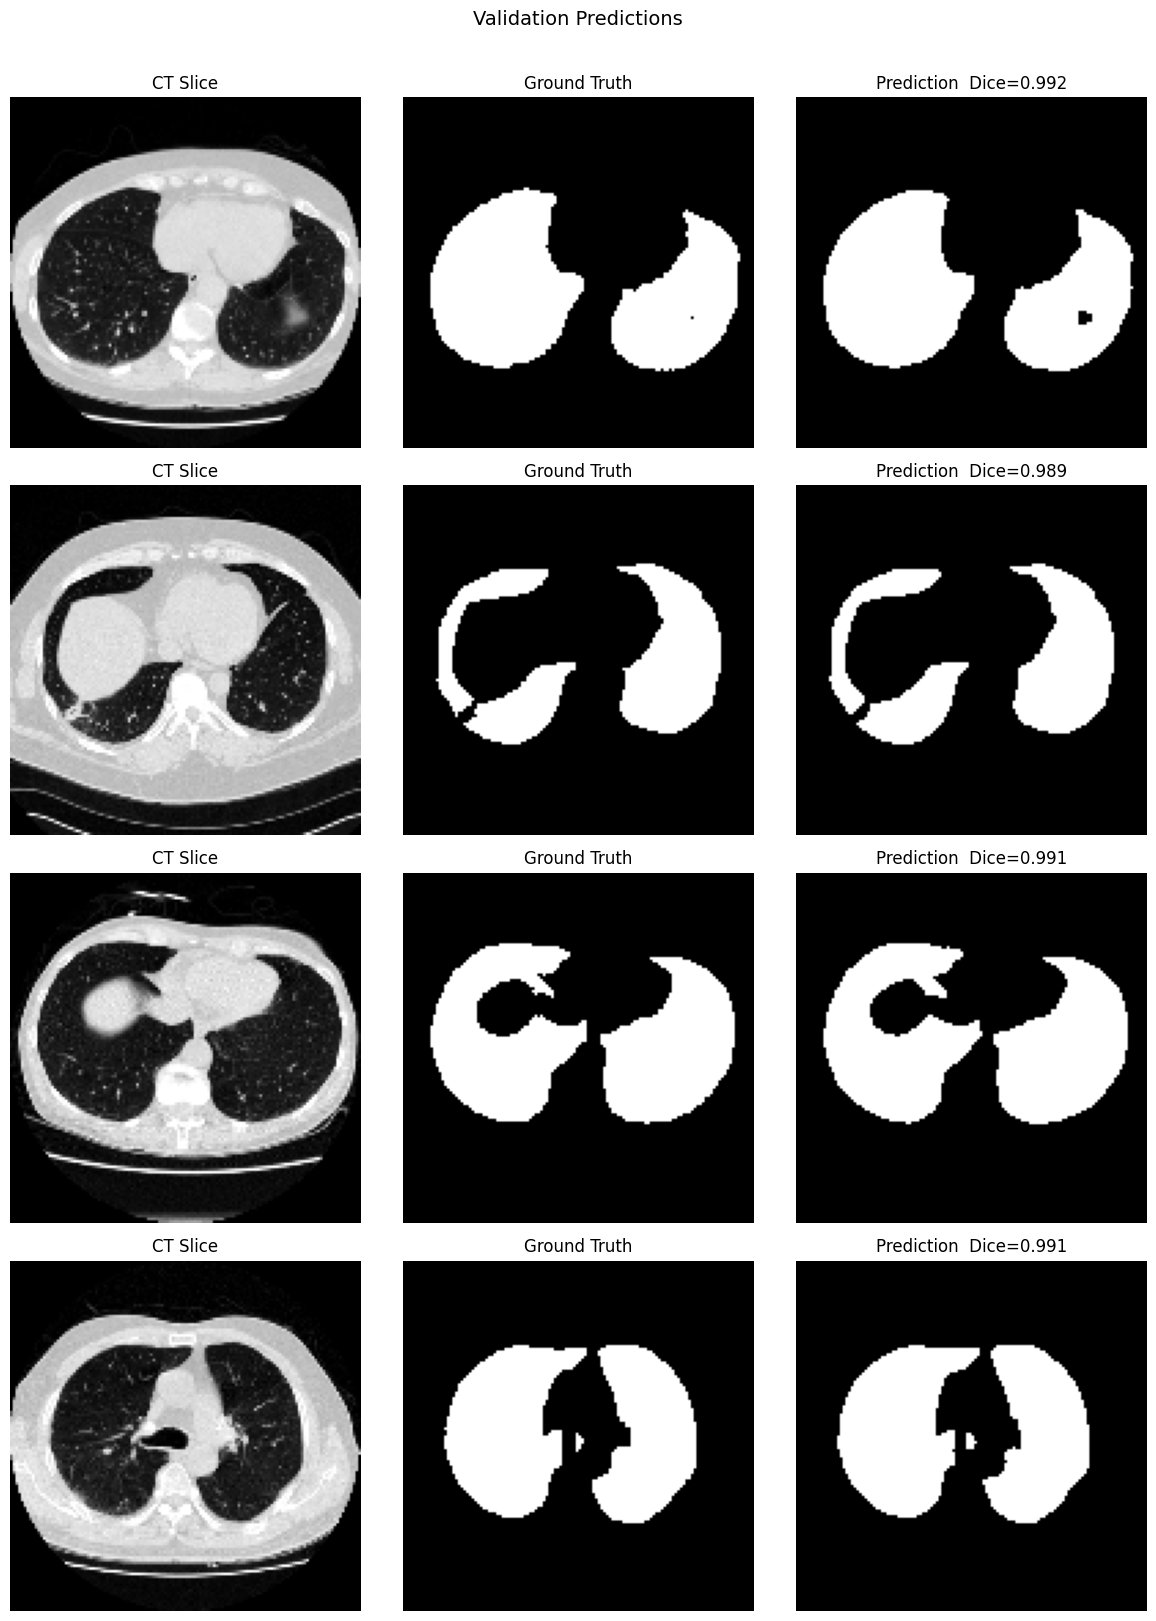

In [ ]:
# ============================================================
# CELL 10 — Prediction visualization
# Shows 4 random val samples in a horizontal layout:
# each row = one sample | cols = CT slice, ground truth, prediction
# ============================================================
assert "model"      in globals(), "Run Cell 7 first."
assert "val_loader" in globals(), "Run Cell 7 first."

N_SAMPLES = 4   # number of samples to visualize

model.eval()
dataset = val_loader.dataset
indices = random.sample(range(len(dataset)), N_SAMPLES)

# Horizontal layout: 3 cols (CT | Ground Truth | Prediction) x N_SAMPLES rows
fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))
fig.suptitle("Validation Predictions", fontsize=14, y=1.01)

with torch.no_grad():
    for row, idx in enumerate(indices):
        sample = dataset[idx]
        if sample is None:
            print("Sample " + str(idx) + " returned None — skipping.", flush=True)
            continue
        img, msk = sample
        logit = model(img.unsqueeze(0).to(DEVICE))
        pred  = (torch.sigmoid(logit) > 0.5).cpu().numpy()[0, 0]
        dice  = compute_metrics(logit, msk.unsqueeze(0).to(DEVICE))["dice"]

        axes[row, 0].imshow(img[0].numpy(), cmap="gray")
        axes[row, 0].set_title("CT Slice"); axes[row, 0].axis("off")

        axes[row, 1].imshow(msk[0].numpy(), cmap="gray")
        axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis("off")

        axes[row, 2].imshow(pred, cmap="gray")
        axes[row, 2].set_title(f"Prediction  Dice={dice:.3f}")
        axes[row, 2].axis("off")

plt.tight_layout()
vis_path = "/content/predictions_sample.png"
plt.savefig(vis_path, bbox_inches="tight", dpi=150)
print(f"Saved -> {vis_path}")
plt.show()